In [1]:
import numpy as np
from skimage.transform import radon
from scipy.stats import entropy
from scipy.ndimage import gaussian_filter, maximum_filter
import cv2


In [ ]:

# Step 1: Mean shift filtering 
import numpy as np

def mean_shift_filter(image, hs=8, hr=16, max_iter=10, eps=1):
    """
    Mean-shift filtering for an image.
    Args:
        image: np.ndarray, input image, grayscale or multichannel.
        hs: int, spatial bandwidth.
        hr: int, range (intensity/color) bandwidth.
        max_iter: int, maximum mean-shift iterations per pixel.
        eps: float, convergence threshold in feature space.
    Returns:
        filtered image (same shape as input)
    """
    # Ensure floating point for computation
    img = image.astype(np.float32)
    h, w = img.shape[:2]
    channels = 1 if img.ndim == 2 else img.shape[2]
    filtered = np.zeros_like(img)

    # Prepare grid for spatial coordinates
    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    spatial = np.stack([Y, X], axis=-1)  # shape: (h, w, 2)

    for i in range(h):
        for j in range(w):
            # Initial feature: (y, x, [channels])
            if channels == 1:
                z = np.array([i, j, img[i, j]])
            else:
                z = np.concatenate(([i, j], img[i, j, :]))

            for _ in range(max_iter):
                # Get local window indices
                min_y = max(0, i - hs)
                max_y = min(h, i + hs + 1)
                min_x = max(0, j - hs)
                max_x = min(w, j + hs + 1)

                region = img[min_y:max_y, min_x:max_x]
                region_spatial = spatial[min_y:max_y, min_x:max_x].reshape(-1, 2)
                region_vals = region.reshape(-1, channels)
                if channels == 1:
                    region_features = np.concatenate([region_spatial, region_vals], axis=1)
                    z_feat = z
                else:
                    region_features = np.concatenate([region_spatial, region_vals], axis=1)
                    z_feat = z

                # Spatial and range (intensity/color) distance, normalized
                spatial_dist = np.linalg.norm(region_features[:, :2] - z_feat[:2], axis=1) / hs
                range_dist = np.linalg.norm(region_features[:, 2:] - z_feat[2:], axis=1) / hr
                mask = np.where((spatial_dist < 1) & (range_dist < 1))[0]

                if mask.size == 0:
                    break
                selected = region_features[mask]

                mean = np.mean(selected, axis=0)
                shift = np.linalg.norm(mean - z_feat)
                z_feat = mean
                if shift < eps:
                    break
            # Write result
            if channels == 1:
                filtered[i, j] = z_feat[2]
            else:
                filtered[i, j, :] = z_feat[2:]
    return filtered.astype(image.dtype)


In [7]:

# Main pipeline
def enhance_ship_wakes_sar(image, M=1.5, N=1.0):
    filtered = mean_shift_filtering_approx(image)
    norm_img = normalize_image(filtered.astype(np.float32))
    radon_coeffs, positions, theta = localized_radon(norm_img)
    detected_peaks = detect_peaks_local(radon_coeffs, M=M, N=N)
    true_wakes = []
    for idx, peaks in enumerate(detected_peaks):
        x, y = positions[idx]
        window = image[y:y + 100, x:x + 100]
        peaks_filtered = []
        for r, c in zip(peaks[0], peaks[1]):
            if r < window.shape[0] and c < window.shape[1]:
                gray_vals = window[:, c]
                ent = shannon_entropy(gray_vals)
                if ent < 4.0:  # Threshold to be tuned
                    peaks_filtered.append((r, c))
        true_wakes.append(peaks_filtered)
    return true_wakes


In [8]:

# Usage:
img= cv2.imread('44.jpg', cv2.IMREAD_GRAYSCALE)
result = enhance_ship_wakes_sar(img)



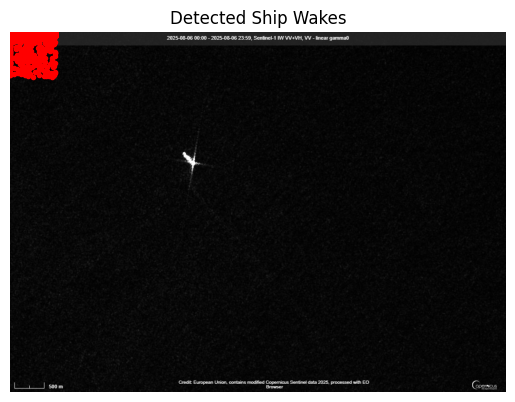

In [9]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray')
for wake_list in result:
    for r, c in wake_list:
        plt.plot(c, r, 'ro', markersize=3)
plt.title('Detected Ship Wakes')
plt.axis('off')
plt.show()